# COSC2753 Assignment 2 — Task 3: Gender & Usage Classification

Predict two targets from fashion item images:
- **gender** — who the item is intended for (Men, Women, Boys, Girls, Unisex)
- **usage** — what occasion it is suitable for (Casual, Formal, Sports, etc.)

Per the assignment spec, these may be treated as two separate classifiers **or** one combined class.
This notebook trains both approaches and compares them.

**Reused from Task 2:** split logic, dataset classes, model architectures (SmallCNN, ResNet18, MultiInputNet),
`fit()` / `run_epoch()` / `evaluate()` training utilities, metadata pipeline, EarlyStopping.

**New in Task 3:** combined-label approach, dual-head model, separate gender/usage evaluation.

## 0. Configuration — switch between TEST and REAL mode here

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
#  MODE SWITCH — set to True for a quick sanity-check run, False for full training
# ─────────────────────────────────────────────────────────────────────────────
TESTING_MODE = True   # <── change this only

if TESTING_MODE:
    # Fast smoke-test: small subset, large batches, few epochs
    SUBSET_SIZE   = 2000    # number of rows sampled from the full train CSV
    BATCH_SIZE    = 128     # larger batch = fewer optimizer steps per epoch
    EPOCHS        = 5       # just enough to confirm the forward pass works
    PATIENCE      = 3       # early-stopping patience
    NUM_WORKERS   = 0       # 0 avoids multiprocessing overhead on small runs
    IMG_SIZE      = (60, 80)  # smaller images → faster data loading
    LR            = 3e-4
    print("[TESTING MODE] Small subset, fast settings.")
else:
    # Full training run — use all data with production-quality settings
    SUBSET_SIZE   = None    # None = use entire dataset
    BATCH_SIZE    = 64
    EPOCHS        = 50
    PATIENCE      = 10
    NUM_WORKERS   = 4
    IMG_SIZE      = (80, 60)  # native image ratio
    LR            = 3e-4
    print("[REAL MODE] Full dataset, full training.")

[TESTING MODE] Small subset, fast settings.


## 1. Imports

In [2]:
import os
import copy
import pickle
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    ConfusionMatrixDisplay
)
import joblib

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
from torchvision.models import (
    resnet18, ResNet18_Weights,
    mobilenet_v3_small, MobileNet_V3_Small_Weights
)
from tqdm.auto import tqdm

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cpu


## 2. Paths

In [3]:
DATA_DIR         = Path("../data/raw/FashionDataset")
TRAIN_CSV        = DATA_DIR / "train" / "styles_train.csv"
IMAGES_TRAIN_DIR = DATA_DIR / "train" / "images_train"
TEST_PRED_CSV    = DATA_DIR / "test" / "styles_prediction.csv"
IMAGES_TEST_DIR  = DATA_DIR / "test" / "images_test"
PROCESSED_DIR    = Path("../data/processed")
OUTPUT_DIR       = Path("../outputs/task3_models")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for p in [TRAIN_CSV, IMAGES_TRAIN_DIR, TEST_PRED_CSV, IMAGES_TEST_DIR]:
    print(f"[{'OK' if p.exists() else 'MISSING'}] {p}")

[OK] ..\data\raw\FashionDataset\train\styles_train.csv
[OK] ..\data\raw\FashionDataset\train\images_train
[OK] ..\data\raw\FashionDataset\test\styles_prediction.csv
[OK] ..\data\raw\FashionDataset\test\images_test


## 3. Load & clean dataset
*(Reused from Task 2 — same cleaning logic)*

In [4]:
df = pd.read_csv(TRAIN_CSV)
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]
df['id'] = df['id'].astype(str).str.strip()

# Keep only rows that have an image file
disk_ids = {p.stem for p in IMAGES_TRAIN_DIR.glob("*.jpg")}
missing  = set(df['id']) - disk_ids
df = df[~df['id'].isin(missing)].reset_index(drop=True)
print(f"Rows after image-alignment: {len(df)}")

# Optional subset for TESTING_MODE
if TESTING_MODE and SUBSET_SIZE:
    df = df.sample(SUBSET_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)
    print(f"[TESTING MODE] Subsampled to {len(df)} rows")

Rows after image-alignment: 38612
[TESTING MODE] Subsampled to 2000 rows


In [5]:
# Duplicate-image groups (needed for a leak-free split)
def file_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

hash_to_group, group_ids = {}, []
for img_id in df['id']:
    h = file_hash(IMAGES_TRAIN_DIR / f"{img_id}.jpg")
    hash_to_group.setdefault(h, img_id)
    group_ids.append(hash_to_group[h])

df['dup_group'] = group_ids
print(f"{df['dup_group'].nunique()} unique image groups in {len(df)} rows")

1999 unique image groups in 2000 rows


## 4. Target label exploration

In [6]:
print("=== gender ===")
print(df['gender'].value_counts())
print("\n=== usage ===")
print(df['usage'].value_counts())

=== gender ===
gender
Men       1050
Women      763
Unisex     114
Boys        43
Girls       30
Name: count, dtype: int64

=== usage ===
usage
Casual          1546
Sports           193
Ethnic           139
Formal           115
Smart Casual       4
Name: count, dtype: int64


In [7]:
# Drop rows with missing target labels — these can't be trained on
before = len(df)
df = df.dropna(subset=['gender', 'usage']).reset_index(drop=True)
print(f"Dropped {before - len(df)} rows with missing gender or usage labels")

# Combined label for the joint-classifier approach
df['gender_usage'] = df['gender'] + '__' + df['usage']
print(f"\nUnique gender x usage combinations: {df['gender_usage'].nunique()}")
print(df['gender_usage'].value_counts().head(15))

Dropped 3 rows with missing gender or usage labels

Unique gender x usage combinations: 15
gender_usage
Men__Casual          784
Women__Casual        589
Men__Sports          142
Women__Ethnic        128
Men__Formal          109
Unisex__Casual       102
Boys__Casual          42
Women__Sports         38
Girls__Casual         29
Unisex__Sports        12
Men__Ethnic           10
Women__Formal          6
Men__Smart Casual      4
Girls__Ethnic          1
Boys__Sports           1
Name: count, dtype: int64


Dropping 6 rows with rare gender_usage combinations


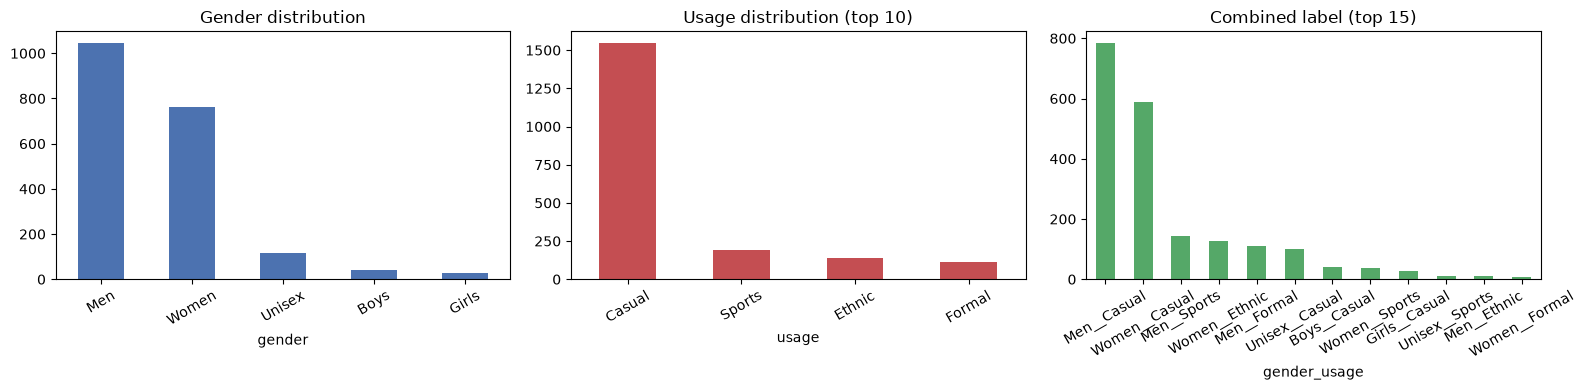

In [8]:
# Drop rare combined classes (< 5 samples) — can't split or train on them reliably
combo_counts = df['gender_usage'].value_counts()
rare_combos  = combo_counts[combo_counts < 5].index
if len(rare_combos):
    print(f"Dropping {df['gender_usage'].isin(rare_combos).sum()} rows with rare gender_usage combinations")
    df = df[~df['gender_usage'].isin(rare_combos)].reset_index(drop=True)

# Distribution plot
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
df['gender'].value_counts().plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Gender distribution'); axes[0].tick_params(axis='x', rotation=30)

df['usage'].value_counts().head(10).plot(kind='bar', ax=axes[1], color='#C44E52')
axes[1].set_title('Usage distribution (top 10)'); axes[1].tick_params(axis='x', rotation=30)

df['gender_usage'].value_counts().head(15).plot(kind='bar', ax=axes[2], color='#55A868')
axes[2].set_title('Combined label (top 15)'); axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 5. Label encoding

In [9]:
gender_enc       = LabelEncoder()
usage_enc        = LabelEncoder()
gender_usage_enc = LabelEncoder()

df['gender_label']       = gender_enc.fit_transform(df['gender'])
df['usage_label']        = usage_enc.fit_transform(df['usage'])
df['gender_usage_label'] = gender_usage_enc.fit_transform(df['gender_usage'])

N_GENDER       = len(gender_enc.classes_)
N_USAGE        = len(usage_enc.classes_)
N_COMBINED     = len(gender_usage_enc.classes_)

print(f"Gender classes ({N_GENDER}):        {list(gender_enc.classes_)}")
print(f"Usage classes ({N_USAGE}):          {list(usage_enc.classes_)}")
print(f"Combined classes ({N_COMBINED}):    {list(gender_usage_enc.classes_)[:8]} ...")

Gender classes (5):        ['Boys', 'Girls', 'Men', 'Unisex', 'Women']
Usage classes (4):          ['Casual', 'Ethnic', 'Formal', 'Sports']
Combined classes (12):    ['Boys__Casual', 'Girls__Casual', 'Men__Casual', 'Men__Ethnic', 'Men__Formal', 'Men__Sports', 'Unisex__Casual', 'Unisex__Sports'] ...


## 6. Train / Validation split
*(Same leak-free strategy as Tasks 1 & 2: StratifiedGroupKFold on masterCategory)*

In [10]:
sgkf = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)

master_counts     = df['masterCategory'].value_counts()
too_rare_master   = master_counts[master_counts < sgkf.get_n_splits()].index
df = df[~df['masterCategory'].isin(too_rare_master)].reset_index(drop=True)

train_idx, val_idx = next(sgkf.split(df, df['masterCategory'], groups=df['dup_group']))
train_data = df.iloc[train_idx].reset_index(drop=True)
val_data   = df.iloc[val_idx].reset_index(drop=True)

print(f"Train: {len(train_data)}, Val: {len(val_data)}")
overlap = set(train_data['dup_group']) & set(val_data['dup_group'])
print(f"Duplicate groups in both splits: {len(overlap)} (should be 0)")

Train: 1491, Val: 498
Duplicate groups in both splits: 0 (should be 0)


## 7. Metadata features
*(Same one-hot pipeline as Task 2 — reused directly)*

In [11]:
from sklearn.preprocessing import OneHotEncoder

# Task 3 metadata: exclude gender and usage (they are the targets — leakage if included)
# Also exclude season (it was Task 2's target — still useful here as a feature)
META_COLS = ['masterCategory', 'subCategory', 'articleType', 'baseColour', 'year', 'season']

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
meta_train = ohe.fit_transform(train_data[META_COLS])
meta_val   = ohe.transform(val_data[META_COLS])
META_DIM   = meta_train.shape[1]

print(f"Metadata feature dimension: {META_DIM}")

joblib.dump(ohe, OUTPUT_DIR / 'ohe_metadata.joblib')
joblib.dump(gender_enc,       OUTPUT_DIR / 'gender_encoder.joblib')
joblib.dump(usage_enc,        OUTPUT_DIR / 'usage_encoder.joblib')
joblib.dump(gender_usage_enc, OUTPUT_DIR / 'gender_usage_encoder.joblib')
print("Encoders saved.")

Metadata feature dimension: 160
Encoders saved.


## 8. Shared utilities
*(Reused verbatim from Task 2)*

In [12]:
# ── Image transforms ──────────────────────────────────────────────────────────
H, W = IMG_SIZE

train_transform = T.Compose([
    T.Resize((H, W)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

eval_transform = T.Compose([
    T.Resize((H, W)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


# ── Weighted sampler for class imbalance ──────────────────────────────────────
def get_weighted_sampler(frame, label_col):
    counts  = frame[label_col].value_counts().to_dict()
    weights = frame[label_col].map(lambda c: 1.0 / counts[c]).values
    return WeightedRandomSampler(weights, len(weights), replacement=True)


# ── Dataset classes ───────────────────────────────────────────────────────────
class FashionImageDataset(Dataset):
    """Image-only dataset for single-label tasks."""
    def __init__(self, frame, image_dir, label_col, transform):
        self.frame     = frame.reset_index(drop=True)
        self.image_dir = image_dir
        self.label_col = label_col
        self.transform = transform

    def __len__(self): return len(self.frame)

    def __getitem__(self, i):
        row = self.frame.iloc[i]
        with Image.open(self.image_dir / f"{row['id']}.jpg") as im:
            img = self.transform(im.convert('RGB'))
        return img, torch.tensor(row[self.label_col], dtype=torch.long)


class MultiInputDataset(Dataset):
    """Image + metadata dataset for single-label tasks."""
    def __init__(self, frame, metadata, labels, image_dir, transform):
        self.frame     = frame.reset_index(drop=True)
        self.metadata  = metadata
        self.labels    = labels
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self): return len(self.frame)

    def __getitem__(self, i):
        with Image.open(self.image_dir / f"{self.frame.iloc[i]['id']}.jpg") as im:
            img = self.transform(im.convert('RGB'))
        meta = torch.tensor(self.metadata[i], dtype=torch.float32)
        lbl  = torch.tensor(self.labels[i],   dtype=torch.long)
        return img, meta, lbl


class DualLabelDataset(Dataset):
    """Image + metadata dataset that returns TWO labels (gender, usage).
    Used by the dual-head model."""
    def __init__(self, frame, metadata, gender_labels, usage_labels, image_dir, transform):
        self.frame         = frame.reset_index(drop=True)
        self.metadata      = metadata
        self.gender_labels = gender_labels
        self.usage_labels  = usage_labels
        self.image_dir     = image_dir
        self.transform     = transform

    def __len__(self): return len(self.frame)

    def __getitem__(self, i):
        with Image.open(self.image_dir / f"{self.frame.iloc[i]['id']}.jpg") as im:
            img = self.transform(im.convert('RGB'))
        meta   = torch.tensor(self.metadata[i],      dtype=torch.float32)
        g_lbl  = torch.tensor(self.gender_labels[i], dtype=torch.long)
        u_lbl  = torch.tensor(self.usage_labels[i],  dtype=torch.long)
        return img, meta, g_lbl, u_lbl

In [13]:
# ── Model building blocks (reused from Task 2) ────────────────────────────────

class ConvBlock(nn.Module):
    """Residual Conv Block with SiLU and BatchNorm."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.act   = nn.SiLU(inplace=True)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.shortcut = (
            nn.Sequential(nn.Conv2d(in_ch, out_ch, 1, bias=False), nn.BatchNorm2d(out_ch))
            if in_ch != out_ch else nn.Sequential()
        )
    def forward(self, x):
        return self.act(self.bn2(self.conv2(self.act(self.bn1(self.conv1(x))))) + self.shortcut(x))


class ImprovedSmallImageEncoder(nn.Module):
    """Upgraded small CNN with residual connections (from Task 2)."""
    def __init__(self, out_dim=128, dropout=0.2):
        super().__init__()
        self.out_dim = out_dim
        self.stage1 = ConvBlock(3, 32);   self.pool1 = nn.MaxPool2d(2)
        self.stage2 = ConvBlock(32, 64);  self.pool2 = nn.MaxPool2d(2)
        self.stage3 = ConvBlock(64, 128); self.pool3 = nn.MaxPool2d(2)
        self.stage4 = ConvBlock(128, 256)
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.proj = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(256, out_dim),
            nn.BatchNorm1d(out_dim), nn.SiLU()
        )
    def forward(self, x):
        x = self.pool1(self.stage1(x))
        x = self.pool2(self.stage2(x))
        x = self.pool3(self.stage3(x))
        return self.proj(self.global_pool(self.stage4(x)).flatten(1))


class PretrainedResNet18Encoder(nn.Module):
    """ImageNet-pretrained ResNet18 as a feature extractor."""
    def __init__(self, out_dim=128):
        super().__init__()
        backbone = resnet18(weights=ResNet18_Weights.DEFAULT)
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.out_dim  = out_dim
        self.proj     = nn.Linear(512, out_dim)
    def forward(self, x):
        return self.proj(self.backbone(x))


class MultiInputNet(nn.Module):
    """Image encoder + metadata MLP → single classification head."""
    def __init__(self, metadata_dim, n_classes, image_encoder):
        super().__init__()
        self.image = image_encoder
        self.meta  = nn.Sequential(
            nn.BatchNorm1d(metadata_dim),
            nn.Linear(metadata_dim, 128), nn.ReLU(), nn.Dropout(0.2)
        )
        self.head = nn.Sequential(
            nn.Linear(image_encoder.out_dim + 128, 256),
            nn.ReLU(), nn.Dropout(0.3), nn.Linear(256, n_classes)
        )
    def forward(self, image, metadata):
        return self.head(torch.cat([self.image(image), self.meta(metadata)], dim=1))


# ── NEW for Task 3: Dual-head model ───────────────────────────────────────────
class DualHeadNet(nn.Module):
    """Shared image+metadata backbone with two separate classification heads:
    one for gender, one for usage. Jointly trained with a weighted sum of losses."""
    def __init__(self, metadata_dim, n_gender, n_usage, image_encoder):
        super().__init__()
        self.image = image_encoder
        self.meta  = nn.Sequential(
            nn.BatchNorm1d(metadata_dim),
            nn.Linear(metadata_dim, 128), nn.ReLU(), nn.Dropout(0.2)
        )
        fused_dim = image_encoder.out_dim + 128
        self.shared = nn.Sequential(
            nn.Linear(fused_dim, 256), nn.ReLU(), nn.Dropout(0.3)
        )
        self.gender_head = nn.Linear(256, n_gender)
        self.usage_head  = nn.Linear(256, n_usage)

    def forward(self, image, metadata):
        fused  = torch.cat([self.image(image), self.meta(metadata)], dim=1)
        shared = self.shared(fused)
        return self.gender_head(shared), self.usage_head(shared)

In [14]:
# ── Training utilities (reused from Task 2) ───────────────────────────────────

class EarlyStopping:
    def __init__(self, patience=5, delta=0, mode='min'):
        assert mode in ('max', 'min')
        self.patience = patience; self.delta = delta; self.mode = mode
        self.best_score = None; self.early_stop = False
        self.counter = 0; self.best_state = None

    def __call__(self, value, model):
        score = value if self.mode == 'max' else -value
        if self.best_score is None or score > self.best_score + self.delta:
            self.best_score = score
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

    def load_best_model(self, model):
        model.load_state_dict(self.best_state)
        return model


def to_device(batch):
    """Move all tensors in batch to DEVICE; last tensor is always the label(s)."""
    *inputs, labels = batch
    return [x.to(DEVICE) for x in inputs], labels.to(DEVICE)


def run_epoch(model, loader, criterion, optimiser=None, desc=''):
    train_mode = optimiser is not None
    model.train() if train_mode else model.eval()
    running_loss, n, preds, actual = 0.0, 0, [], []
    with torch.set_grad_enabled(train_mode):
        for batch in tqdm(loader, desc=desc, leave=train_mode):
            inputs, labels = to_device(batch)
            logits = model(*inputs)
            loss   = criterion(logits, labels)
            if train_mode:
                optimiser.zero_grad(); loss.backward(); optimiser.step()
            running_loss += loss.item() * labels.size(0)
            n += labels.size(0)
            preds.extend(logits.argmax(1).detach().cpu().numpy())
            actual.extend(labels.cpu().numpy())
    return running_loss / n, f1_score(actual, preds, average='macro', zero_division=0)


def fit(model, loader_tr, loader_va, model_name='model', patience=PATIENCE, lr=LR):
    criterion    = nn.CrossEntropyLoss()
    optimiser    = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler    = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.5, patience=2)
    stopper      = EarlyStopping(patience=patience, mode='min')
    history      = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
    best_val_f1  = None; best_epoch = None

    for epoch in range(EPOCHS):
        tag = f'{model_name} {epoch+1}/{EPOCHS}'
        tr_loss, tr_f1 = run_epoch(model, loader_tr, criterion, optimiser, desc=f'{tag} train')
        va_loss, va_f1 = run_epoch(model, loader_va, criterion, None,      desc=f'{tag} val')
        history['train_loss'].append(tr_loss); history['val_loss'].append(va_loss)
        history['train_f1'].append(tr_f1);    history['val_f1'].append(va_f1)
        current_lr = optimiser.param_groups[0]['lr']
        print(f'Epoch {epoch+1}/{EPOCHS} — tr_loss={tr_loss:.4f}  va_loss={va_loss:.4f}  '
              f'tr_f1={tr_f1:.4f}  va_f1={va_f1:.4f}  lr={current_lr:.2e}')
        scheduler.step(va_loss)
        stopper(va_loss, model)
        if stopper.counter == 0:
            best_val_f1 = va_f1; best_epoch = epoch + 1
        if stopper.early_stop:
            print(f'Early stopping at epoch {epoch+1} (best epoch={best_epoch})')
            break

    model = stopper.load_best_model(model)
    plot_training_curves(history, model_name)
    print(f'>>> {model_name}: best epoch={best_epoch}, val_f1={best_val_f1:.4f}')
    return model, best_val_f1, best_epoch


def evaluate(model, loader, label_col='single'):
    model.eval(); preds, actual = [], []
    with torch.no_grad():
        for batch in loader:
            inputs, labels = to_device(batch)
            preds.extend(model(*inputs).argmax(1).cpu().numpy())
            actual.extend(labels.cpu().numpy())
    return f1_score(actual, preds, average='macro', zero_division=0)


def plot_training_curves(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    axes[0].plot(history['train_loss'], label='Train'); axes[0].plot(history['val_loss'], label='Val')
    axes[0].set_title('Loss'); axes[0].legend()
    axes[1].plot(history['train_f1'], label='Train'); axes[1].plot(history['val_f1'], label='Val')
    axes[1].set_title('Macro-F1'); axes[1].legend()
    plt.tight_layout(rect=[0, 0, 1, 0.93]); plt.show()

## 9. Approach A — Two separate classifiers (gender | usage)

Train one model for each target independently. Simpler, but ignores the correlation between gender and usage.

In [15]:
# ── Labels ────────────────────────────────────────────────────────────────────
y_gender_train = train_data['gender_label'].values
y_gender_val   = val_data['gender_label'].values
y_usage_train  = train_data['usage_label'].values
y_usage_val    = val_data['usage_label'].values

# ── Weighted samplers ─────────────────────────────────────────────────────────
sampler_gender = get_weighted_sampler(train_data, 'gender_label')
sampler_usage  = get_weighted_sampler(train_data, 'usage_label')

c:\Users\Admin\OneDrive - RMIT University\Year 1\Machine Learning\COSC2753-Assignment-2\venv\Lib\site-packages\torch\utils\data\sampler.py:264: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  weights_tensor = torch.as_tensor(weights, dtype=torch.double)


In [16]:
# ─── 9.1 Baseline: Logistic Regression on metadata only ──────────────────────
BASELINE_DIR = OUTPUT_DIR / 'baselines'
BASELINE_DIR.mkdir(exist_ok=True)

logreg_gender = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
logreg_gender.fit(meta_train, y_gender_train)
logreg_gender_f1 = f1_score(y_gender_val, logreg_gender.predict(meta_val), average='macro', zero_division=0)

logreg_usage = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
logreg_usage.fit(meta_train, y_usage_train)
logreg_usage_f1 = f1_score(y_usage_val, logreg_usage.predict(meta_val), average='macro', zero_division=0)

print(f'Logistic Regression — gender val F1: {logreg_gender_f1:.4f}')
print(f'Logistic Regression — usage  val F1: {logreg_usage_f1:.4f}')

print('\nGender classification report:')
print(classification_report(y_gender_val, logreg_gender.predict(meta_val),
                             target_names=gender_enc.classes_, zero_division=0))
print('\nUsage classification report:')
print(classification_report(y_usage_val, logreg_usage.predict(meta_val),
                             target_names=usage_enc.classes_, zero_division=0))

joblib.dump(logreg_gender, BASELINE_DIR / 'logreg_gender.joblib')
joblib.dump(logreg_usage,  BASELINE_DIR / 'logreg_usage.joblib')

Logistic Regression — gender val F1: 0.4667
Logistic Regression — usage  val F1: 0.7312

Gender classification report:
              precision    recall  f1-score   support

        Boys       0.14      0.50      0.22        14
       Girls       0.21      0.45      0.29        11
         Men       0.79      0.63      0.70       260
      Unisex       0.28      0.73      0.40        30
       Women       0.85      0.63      0.72       183

    accuracy                           0.63       498
   macro avg       0.45      0.59      0.47       498
weighted avg       0.75      0.63      0.67       498


Usage classification report:
              precision    recall  f1-score   support

      Casual       0.97      0.75      0.85       385
      Ethnic       0.92      0.94      0.93        36
      Formal       0.34      1.00      0.51        25
      Sports       0.50      0.87      0.63        52

    accuracy                           0.79       498
   macro avg       0.68      0.89   

['..\\outputs\\task3_models\\baselines\\logreg_usage.joblib']

MultiInput-ImprovedCNN (gender) 1/5 train:   0%|          | 0/12 [00:00<?, ?it/s]

MultiInput-ImprovedCNN (gender) 1/5 val:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 1/5 — tr_loss=1.4636  va_loss=1.6745  tr_f1=0.3919  va_f1=0.0086  lr=3.00e-04


MultiInput-ImprovedCNN (gender) 2/5 train:   0%|          | 0/12 [00:00<?, ?it/s]

MultiInput-ImprovedCNN (gender) 2/5 val:   0%|          | 0/4 [00:00<?, ?it/s]

...

MultiInput-ImprovedCNN (gender) 4/5 val:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 4/5 — tr_loss=0.7046  va_loss=0.8234  tr_f1=0.7747  va_f1=0.5635  lr=3.00e-04


MultiInput-ImprovedCNN (gender) 5/5 train:   0%|          | 0/12 [00:00<?, ?it/s]

MultiInput-ImprovedCNN (gender) 5/5 val:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 5/5 — tr_loss=0.5434  va_loss=0.7952  tr_f1=0.8246  va_f1=0.5498  lr=3.00e-04


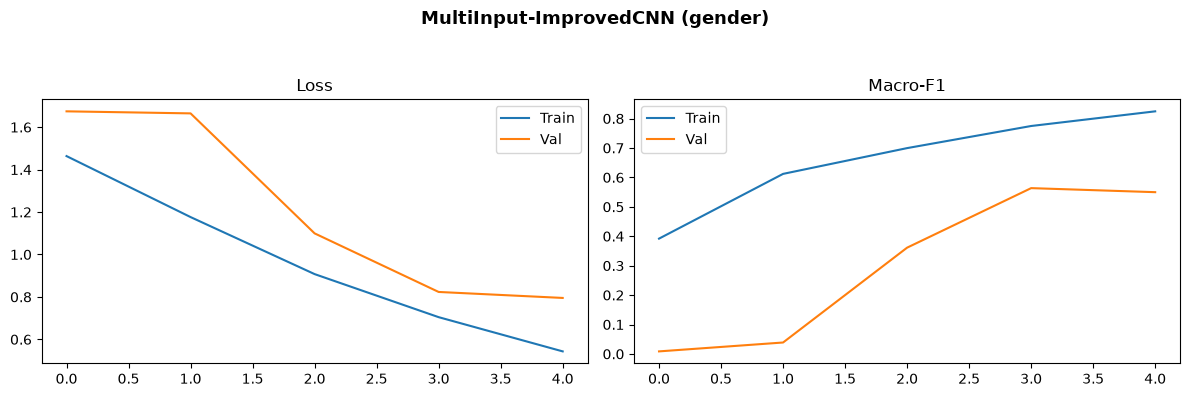

>>> MultiInput-ImprovedCNN (gender): best epoch=5, val_f1=0.5498
Saved gender model — val_f1=0.5498


In [17]:
# ─── 9.2 Gender classifier — MultiInput + ImprovedSmallCNN ───────────────────
train_ds_gender = MultiInputDataset(train_data, meta_train, y_gender_train, IMAGES_TRAIN_DIR, train_transform)
val_ds_gender   = MultiInputDataset(val_data,   meta_val,   y_gender_val,   IMAGES_TRAIN_DIR, eval_transform)

train_loader_gender = DataLoader(train_ds_gender, batch_size=BATCH_SIZE, sampler=sampler_gender,
                                  num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))
val_loader_gender   = DataLoader(val_ds_gender,   batch_size=BATCH_SIZE, shuffle=False,
                                  num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))

torch.manual_seed(RANDOM_STATE)
gender_model, gender_f1, gender_epoch = fit(
    MultiInputNet(META_DIM, N_GENDER, ImprovedSmallImageEncoder(out_dim=128)).to(DEVICE),
    train_loader_gender, val_loader_gender,
    model_name='MultiInput-ImprovedCNN (gender)'
)

torch.save(gender_model.state_dict(), OUTPUT_DIR / 'gender_multiinput_smallcnn.pt')
print(f'Saved gender model — val_f1={gender_f1:.4f}')

MultiInput-ResNet18Pretrained (gender) 1/5 train:   0%|          | 0/12 [00:00<?, ?it/s]

MultiInput-ResNet18Pretrained (gender) 1/5 val:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 1/5 — tr_loss=1.0372  va_loss=0.9586  tr_f1=0.6286  va_f1=0.5647  lr=3.00e-04


MultiInput-ResNet18Pretrained (gender) 2/5 train:   0%|          | 0/12 [00:00<?, ?it/s]

MultiInput-ResNet18Pretrained (gender) 2/5 val:   0%|          | 0/4 [00:00<?, ?it/s]

...

MultiInput-ResNet18Pretrained (gender) 4/5 val:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 4/5 — tr_loss=0.1406  va_loss=0.6877  tr_f1=0.9487  va_f1=0.6433  lr=3.00e-04


MultiInput-ResNet18Pretrained (gender) 5/5 train:   0%|          | 0/12 [00:00<?, ?it/s]

MultiInput-ResNet18Pretrained (gender) 5/5 val:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 5/5 — tr_loss=0.1241  va_loss=0.6487  tr_f1=0.9576  va_f1=0.6343  lr=3.00e-04


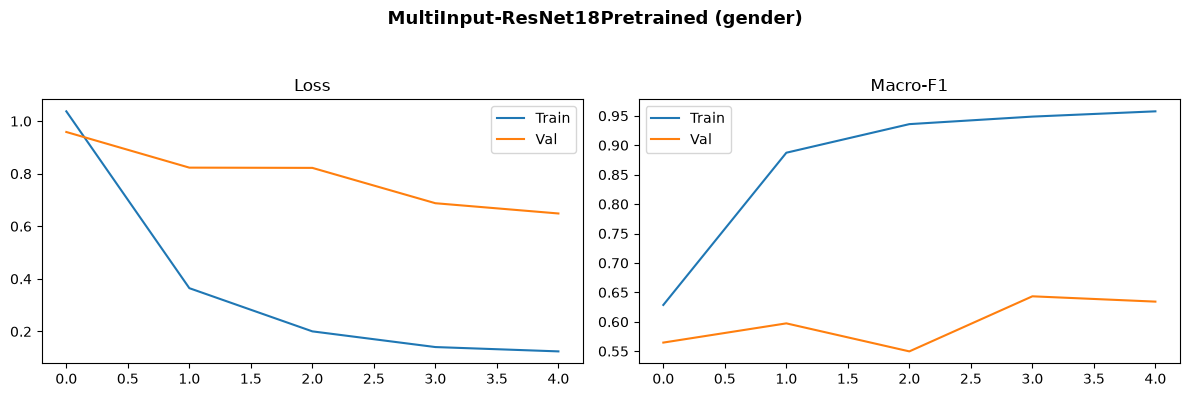

>>> MultiInput-ResNet18Pretrained (gender): best epoch=5, val_f1=0.6343
Pretrained ResNet18 gender — val_f1=0.6343


In [18]:
# ─── 9.3 Gender classifier — MultiInput + Pretrained ResNet18 ────────────────
torch.manual_seed(RANDOM_STATE)
gender_resnet_model, gender_resnet_f1, gender_resnet_epoch = fit(
    MultiInputNet(META_DIM, N_GENDER, PretrainedResNet18Encoder(out_dim=128)).to(DEVICE),
    train_loader_gender, val_loader_gender,
    model_name='MultiInput-ResNet18Pretrained (gender)'
)
print(f'Pretrained ResNet18 gender — val_f1={gender_resnet_f1:.4f}')

MultiInput-ImprovedCNN (usage) 1/5 train:   0%|          | 0/12 [00:00<?, ?it/s]

MultiInput-ImprovedCNN (usage) 1/5 val:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 1/5 — tr_loss=1.2639  va_loss=1.3958  tr_f1=0.4764  va_f1=0.0931  lr=3.00e-04


MultiInput-ImprovedCNN (usage) 2/5 train:   0%|          | 0/12 [00:00<?, ?it/s]

MultiInput-ImprovedCNN (usage) 2/5 val:   0%|          | 0/4 [00:00<?, ?it/s]

...

MultiInput-ImprovedCNN (usage) 4/5 val:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 4/5 — tr_loss=0.6126  va_loss=0.9598  tr_f1=0.7785  va_f1=0.5037  lr=3.00e-04


MultiInput-ImprovedCNN (usage) 5/5 train:   0%|          | 0/12 [00:00<?, ?it/s]

MultiInput-ImprovedCNN (usage) 5/5 val:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 5/5 — tr_loss=0.4994  va_loss=0.9530  tr_f1=0.8082  va_f1=0.5025  lr=3.00e-04


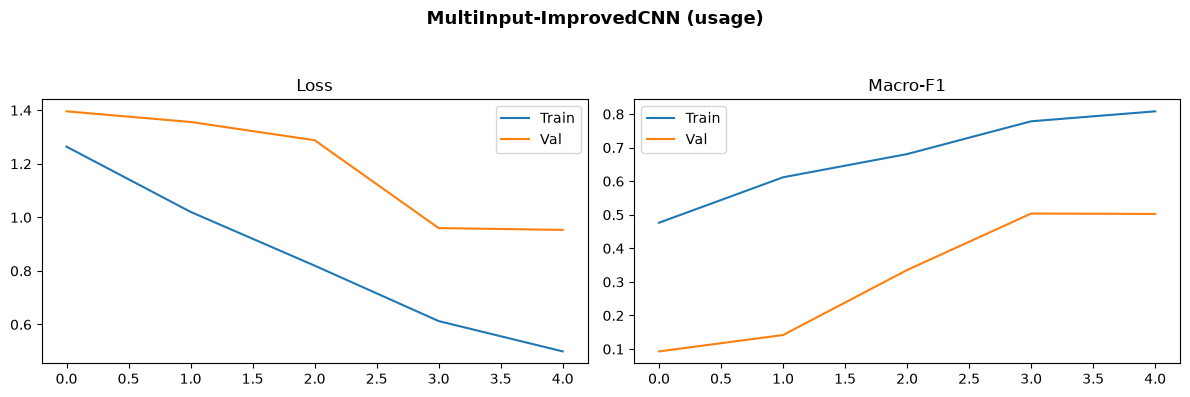

>>> MultiInput-ImprovedCNN (usage): best epoch=5, val_f1=0.5025
Saved usage model — val_f1=0.5025


In [19]:
# ─── 9.4 Usage classifier — MultiInput + ImprovedSmallCNN ────────────────────
train_ds_usage = MultiInputDataset(train_data, meta_train, y_usage_train, IMAGES_TRAIN_DIR, train_transform)
val_ds_usage   = MultiInputDataset(val_data,   meta_val,   y_usage_val,   IMAGES_TRAIN_DIR, eval_transform)

train_loader_usage = DataLoader(train_ds_usage, batch_size=BATCH_SIZE, sampler=sampler_usage,
                                 num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))
val_loader_usage   = DataLoader(val_ds_usage,   batch_size=BATCH_SIZE, shuffle=False,
                                 num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))

torch.manual_seed(RANDOM_STATE)
usage_model, usage_f1, usage_epoch = fit(
    MultiInputNet(META_DIM, N_USAGE, ImprovedSmallImageEncoder(out_dim=128)).to(DEVICE),
    train_loader_usage, val_loader_usage,
    model_name='MultiInput-ImprovedCNN (usage)'
)

torch.save(usage_model.state_dict(), OUTPUT_DIR / 'usage_multiinput_smallcnn.pt')
print(f'Saved usage model — val_f1={usage_f1:.4f}')

MultiInput-ResNet18Pretrained (usage) 1/5 train:   0%|          | 0/12 [00:00<?, ?it/s]

MultiInput-ResNet18Pretrained (usage) 1/5 val:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 1/5 — tr_loss=0.8879  va_loss=1.3065  tr_f1=0.6633  va_f1=0.4337  lr=3.00e-04


MultiInput-ResNet18Pretrained (usage) 2/5 train:   0%|          | 0/12 [00:00<?, ?it/s]

MultiInput-ResNet18Pretrained (usage) 2/5 val:   0%|          | 0/4 [00:00<?, ?it/s]

...

MultiInput-ResNet18Pretrained (usage) 4/5 val:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 4/5 — tr_loss=0.1834  va_loss=0.7122  tr_f1=0.9374  va_f1=0.6399  lr=3.00e-04


MultiInput-ResNet18Pretrained (usage) 5/5 train:   0%|          | 0/12 [00:00<?, ?it/s]

MultiInput-ResNet18Pretrained (usage) 5/5 val:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 5/5 — tr_loss=0.1436  va_loss=0.5154  tr_f1=0.9567  va_f1=0.7608  lr=3.00e-04


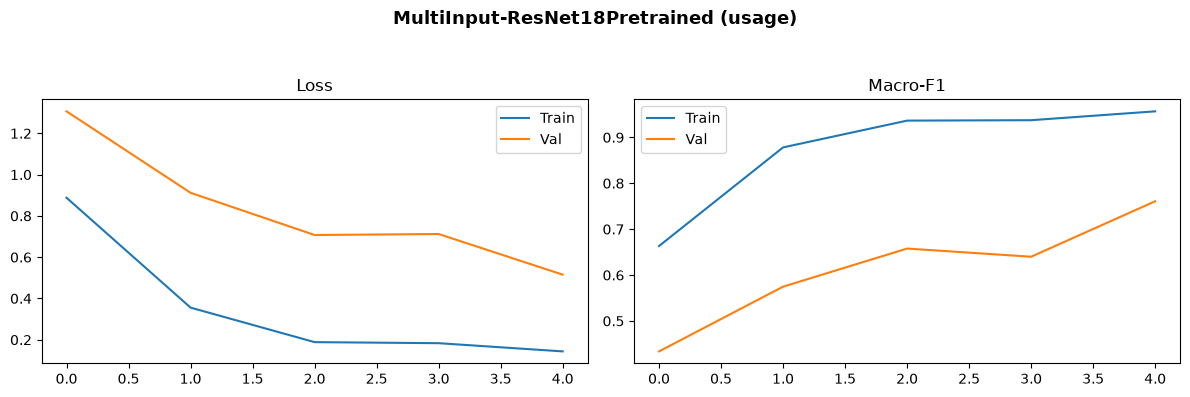

>>> MultiInput-ResNet18Pretrained (usage): best epoch=5, val_f1=0.7608
Pretrained ResNet18 usage — val_f1=0.7608


In [20]:
# ─── 9.5 Usage classifier — MultiInput + Pretrained ResNet18 ─────────────────
torch.manual_seed(RANDOM_STATE)
usage_resnet_model, usage_resnet_f1, usage_resnet_epoch = fit(
    MultiInputNet(META_DIM, N_USAGE, PretrainedResNet18Encoder(out_dim=128)).to(DEVICE),
    train_loader_usage, val_loader_usage,
    model_name='MultiInput-ResNet18Pretrained (usage)'
)
print(f'Pretrained ResNet18 usage — val_f1={usage_resnet_f1:.4f}')

## 10. Approach B — Single combined-label classifier (gender × usage)

Treats gender_usage as one combined class. Learns the joint distribution but has more classes and sparser per-class data.

MultiInput-ImprovedCNN (gender x usage combined) 1/5 train:   0%|          | 0/12 [00:00<?, ?it/s]

MultiInput-ImprovedCNN (gender x usage combined) 1/5 val:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 1/5 — tr_loss=2.3620  va_loss=2.4966  tr_f1=0.2139  va_f1=0.0245  lr=3.00e-04


MultiInput-ImprovedCNN (gender x usage combined) 2/5 train:   0%|          | 0/12 [00:00<?, ?it/s]

MultiInput-ImprovedCNN (gender x usage combined) 2/5 val:   0%|          | 0/4 [00:00<?, ?it/s]

...

MultiInput-ImprovedCNN (gender x usage combined) 4/5 val:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 4/5 — tr_loss=1.5404  va_loss=2.3220  tr_f1=0.5881  va_f1=0.1428  lr=3.00e-04


MultiInput-ImprovedCNN (gender x usage combined) 5/5 train:   0%|          | 0/12 [00:00<?, ?it/s]

MultiInput-ImprovedCNN (gender x usage combined) 5/5 val:   0%|          | 0/4 [00:00<?, ?it/s]

Epoch 5/5 — tr_loss=1.2984  va_loss=1.9493  tr_f1=0.6472  va_f1=0.2779  lr=3.00e-04


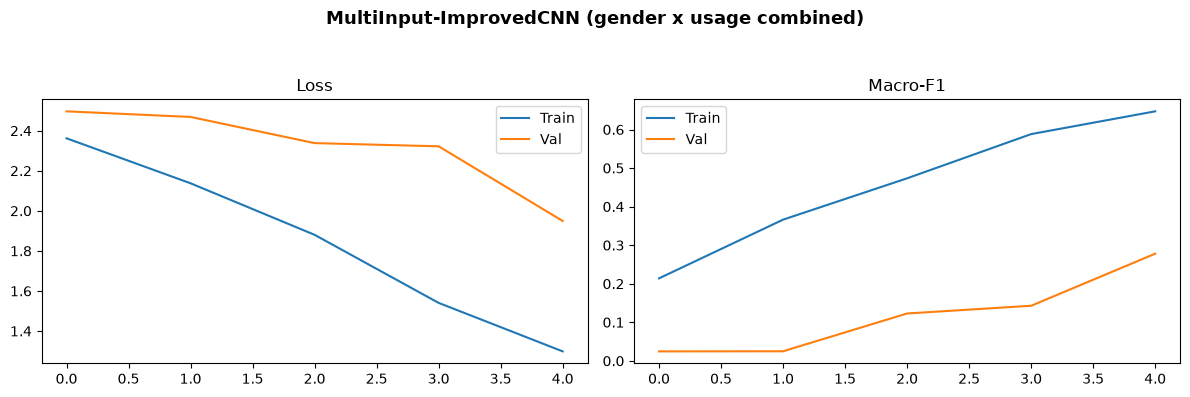

>>> MultiInput-ImprovedCNN (gender x usage combined): best epoch=5, val_f1=0.2779
Saved combined model — val_f1=0.2779


In [21]:
y_combined_train = train_data['gender_usage_label'].values
y_combined_val   = val_data['gender_usage_label'].values
sampler_combined = get_weighted_sampler(train_data, 'gender_usage_label')

train_ds_combined = MultiInputDataset(train_data, meta_train, y_combined_train, IMAGES_TRAIN_DIR, train_transform)
val_ds_combined   = MultiInputDataset(val_data,   meta_val,   y_combined_val,   IMAGES_TRAIN_DIR, eval_transform)

train_loader_combined = DataLoader(train_ds_combined, batch_size=BATCH_SIZE, sampler=sampler_combined,
                                    num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))
val_loader_combined   = DataLoader(val_ds_combined,   batch_size=BATCH_SIZE, shuffle=False,
                                    num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))

torch.manual_seed(RANDOM_STATE)
combined_model, combined_f1, combined_epoch = fit(
    MultiInputNet(META_DIM, N_COMBINED, ImprovedSmallImageEncoder(out_dim=128)).to(DEVICE),
    train_loader_combined, val_loader_combined,
    model_name='MultiInput-ImprovedCNN (gender x usage combined)'
)

torch.save(combined_model.state_dict(), OUTPUT_DIR / 'combined_gender_usage_smallcnn.pt')
print(f'Saved combined model — val_f1={combined_f1:.4f}')

## 11. Approach C — Dual-head model (shared backbone, two heads)

Trains one model that simultaneously predicts both gender and usage from a shared representation.
Loss = α × gender_loss + (1−α) × usage_loss.

DualHead-ImprovedCNN (gender + usage) 1/5 train:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 1/5 — tr_loss=1.2905  va_loss=1.3362  tr_f1_g=0.2403  tr_f1_u=0.2292  va_f1_g=0.1092  va_f1_u=0.2180


DualHead-ImprovedCNN (gender + usage) 2/5 train:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 2/5 — tr_loss=1.0110  va_loss=1.0974  tr_f1_g=0.2538  tr_f1_u=0.2187  va_f1_g=0.1770  va_f1_u=0.2180


DualHead-ImprovedCNN (gender + usage) 3/5 train:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 3/5 — tr_loss=0.8178  va_loss=0.8683  tr_f1_g=0.2886  tr_f1_u=0.2187  va_f1_g=0.3005  va_f1_u=0.2180


DualHead-ImprovedCNN (gender + usage) 4/5 train:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 4/5 — tr_loss=0.7022  va_loss=0.7344  tr_f1_g=0.3088  tr_f1_u=0.2187  va_f1_g=0.2931  va_f1_u=0.2180


DualHead-ImprovedCNN (gender + usage) 5/5 train:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 5/5 — tr_loss=0.6186  va_loss=0.6338  tr_f1_g=0.3267  tr_f1_u=0.2187  va_f1_g=0.3098  va_f1_u=0.2180


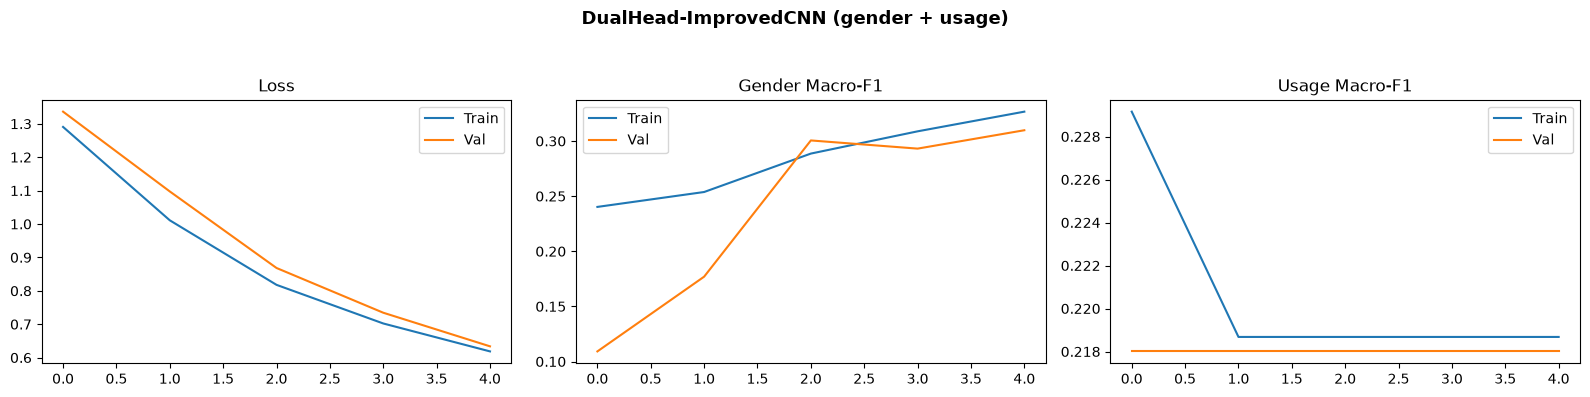

>>> Best epoch=5  val_f1_gender=0.3098  val_f1_usage=0.2180
Dual-head saved — gender_f1=0.3098  usage_f1=0.2180


In [22]:
ALPHA = 0.5   # weight balance between gender and usage losses

train_ds_dual = DualLabelDataset(
    train_data, meta_train, y_gender_train, y_usage_train, IMAGES_TRAIN_DIR, train_transform)
val_ds_dual   = DualLabelDataset(
    val_data,   meta_val,   y_gender_val,   y_usage_val,   IMAGES_TRAIN_DIR, eval_transform)

train_loader_dual = DataLoader(train_ds_dual, batch_size=BATCH_SIZE, shuffle=True,
                                num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))
val_loader_dual   = DataLoader(val_ds_dual,   batch_size=BATCH_SIZE, shuffle=False,
                                num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))


def fit_dual(model, loader_tr, loader_va, model_name='dual_model', patience=PATIENCE, lr=LR):
    """Training loop for the dual-head model. Returns gender F1, usage F1."""
    criterion  = nn.CrossEntropyLoss()
    optimiser  = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimiser, mode='min', factor=0.5, patience=2)
    stopper    = EarlyStopping(patience=patience, mode='min')
    history    = {'train_loss': [], 'val_loss': [], 'train_f1_g': [], 'train_f1_u': [],
                  'val_f1_g':   [], 'val_f1_u': []}
    best_val_loss = None; best_epoch = None; best_val_f1_g = None; best_val_f1_u = None

    for epoch in range(EPOCHS):
        # ── Train ──
        model.train()
        tr_loss, tr_pg, tr_pu, tr_ag, tr_au = 0.0, [], [], [], []
        for img, meta, g_lbl, u_lbl in tqdm(loader_tr, desc=f'{model_name} {epoch+1}/{EPOCHS} train', leave=True):
            img, meta, g_lbl, u_lbl = img.to(DEVICE), meta.to(DEVICE), g_lbl.to(DEVICE), u_lbl.to(DEVICE)
            g_logit, u_logit = model(img, meta)
            loss = ALPHA * criterion(g_logit, g_lbl) + (1 - ALPHA) * criterion(u_logit, u_lbl)
            optimiser.zero_grad(); loss.backward(); optimiser.step()
            tr_loss += loss.item() * g_lbl.size(0)
            tr_pg.extend(g_logit.argmax(1).cpu().numpy()); tr_ag.extend(g_lbl.cpu().numpy())
            tr_pu.extend(u_logit.argmax(1).cpu().numpy()); tr_au.extend(u_lbl.cpu().numpy())
        tr_loss /= len(train_data)
        tr_f1_g = f1_score(tr_ag, tr_pg, average='macro', zero_division=0)
        tr_f1_u = f1_score(tr_au, tr_pu, average='macro', zero_division=0)

        # ── Validate ──
        model.eval()
        va_loss, va_pg, va_pu, va_ag, va_au = 0.0, [], [], [], []
        with torch.no_grad():
            for img, meta, g_lbl, u_lbl in loader_va:
                img, meta, g_lbl, u_lbl = img.to(DEVICE), meta.to(DEVICE), g_lbl.to(DEVICE), u_lbl.to(DEVICE)
                g_logit, u_logit = model(img, meta)
                loss = ALPHA * criterion(g_logit, g_lbl) + (1 - ALPHA) * criterion(u_logit, u_lbl)
                va_loss += loss.item() * g_lbl.size(0)
                va_pg.extend(g_logit.argmax(1).cpu().numpy()); va_ag.extend(g_lbl.cpu().numpy())
                va_pu.extend(u_logit.argmax(1).cpu().numpy()); va_au.extend(u_lbl.cpu().numpy())
        va_loss /= len(val_data)
        va_f1_g = f1_score(va_ag, va_pg, average='macro', zero_division=0)
        va_f1_u = f1_score(va_au, va_pu, average='macro', zero_division=0)

        for k, v in zip(['train_loss','val_loss','train_f1_g','train_f1_u','val_f1_g','val_f1_u'],
                         [tr_loss, va_loss, tr_f1_g, tr_f1_u, va_f1_g, va_f1_u]):
            history[k].append(v)

        print(f'Epoch {epoch+1}/{EPOCHS} — tr_loss={tr_loss:.4f}  va_loss={va_loss:.4f}  '
              f'tr_f1_g={tr_f1_g:.4f}  tr_f1_u={tr_f1_u:.4f}  '
              f'va_f1_g={va_f1_g:.4f}  va_f1_u={va_f1_u:.4f}')

        scheduler.step(va_loss)
        stopper(va_loss, model)
        if stopper.counter == 0:
            best_val_loss = va_loss; best_epoch = epoch + 1
            best_val_f1_g = va_f1_g; best_val_f1_u = va_f1_u
        if stopper.early_stop:
            print(f'Early stopping at epoch {epoch+1} (best={best_epoch})')
            break

    model = stopper.load_best_model(model)

    # Plot training curves
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(model_name, fontsize=13, fontweight='bold')
    axes[0].plot(history['train_loss'], label='Train'); axes[0].plot(history['val_loss'], label='Val')
    axes[0].set_title('Loss'); axes[0].legend()
    axes[1].plot(history['train_f1_g'], label='Train'); axes[1].plot(history['val_f1_g'], label='Val')
    axes[1].set_title('Gender Macro-F1'); axes[1].legend()
    axes[2].plot(history['train_f1_u'], label='Train'); axes[2].plot(history['val_f1_u'], label='Val')
    axes[2].set_title('Usage Macro-F1'); axes[2].legend()
    plt.tight_layout(rect=[0, 0, 1, 0.93]); plt.show()

    print(f'>>> Best epoch={best_epoch}  val_f1_gender={best_val_f1_g:.4f}  val_f1_usage={best_val_f1_u:.4f}')
    return model, best_val_f1_g, best_val_f1_u, best_epoch


torch.manual_seed(RANDOM_STATE)
dual_model, dual_f1_g, dual_f1_u, dual_epoch = fit_dual(
    DualHeadNet(META_DIM, N_GENDER, N_USAGE, ImprovedSmallImageEncoder(out_dim=128)).to(DEVICE),
    train_loader_dual, val_loader_dual,
    model_name='DualHead-ImprovedCNN (gender + usage)'
)

torch.save(dual_model.state_dict(), OUTPUT_DIR / 'dual_head_gender_usage.pt')
print(f'Dual-head saved — gender_f1={dual_f1_g:.4f}  usage_f1={dual_f1_u:.4f}')

## 12. Evaluation & comparison across all approaches

In [23]:
# ── Helper: evaluate dual-head on val set ────────────────────────────────────
def evaluate_dual(model, loader):
    model.eval(); pg, pu, ag, au = [], [], [], []
    with torch.no_grad():
        for img, meta, g_lbl, u_lbl in loader:
            img, meta = img.to(DEVICE), meta.to(DEVICE)
            g_logit, u_logit = model(img, meta)
            pg.extend(g_logit.argmax(1).cpu().numpy()); ag.extend(g_lbl.numpy())
            pu.extend(u_logit.argmax(1).cpu().numpy()); au.extend(u_lbl.numpy())
    f1_g = f1_score(ag, pg, average='macro', zero_division=0)
    f1_u = f1_score(au, pu, average='macro', zero_division=0)
    return f1_g, f1_u, np.array(pg), np.array(pu), np.array(ag), np.array(au)


# ── Run evaluations ───────────────────────────────────────────────────────────
# Approach A
f1_g_cnn    = evaluate(gender_model,        val_loader_gender)
f1_g_resnet = evaluate(gender_resnet_model, val_loader_gender)
f1_u_cnn    = evaluate(usage_model,         val_loader_usage)
f1_u_resnet = evaluate(usage_resnet_model,  val_loader_usage)

# Approach B — decode combined label back to gender/usage
combined_model.eval(); cp, ca = [], []
with torch.no_grad():
    for batch in val_loader_combined:
        inputs, labels = to_device(batch)
        cp.extend(combined_model(*inputs).argmax(1).cpu().numpy())
        ca.extend(labels.cpu().numpy())

# Decode combined labels back to gender and usage
combo_classes   = gender_usage_enc.classes_
pred_gender_B   = [gender_enc.transform([c.split('__')[0]])[0] for c in gender_usage_enc.inverse_transform(cp)]
pred_usage_B    = [usage_enc.transform([c.split('__')[1]])[0]  for c in gender_usage_enc.inverse_transform(cp)]
true_gender_B   = val_data['gender_label'].values
true_usage_B    = val_data['usage_label'].values
f1_g_combined   = f1_score(true_gender_B, pred_gender_B, average='macro', zero_division=0)
f1_u_combined   = f1_score(true_usage_B,  pred_usage_B,  average='macro', zero_division=0)

# Approach C — run ONCE and keep the raw predictions (previously this was
# re-run two more times in the confusion-matrix cell, tripling compute for
# no reason since the model and val loader don't change)
f1_g_dual, f1_u_dual, pg_dual, pu_dual, ag_dual, au_dual = evaluate_dual(dual_model, val_loader_dual)


In [24]:
# ── Summary table ─────────────────────────────────────────────────────────────
results_df = pd.DataFrame({
    'Model': [
        'LogReg (metadata baseline)',
        'A — MultiInput-SmallCNN (gender)',
        'A — MultiInput-ResNet18 (gender)',
        'A — MultiInput-SmallCNN (usage)',
        'A — MultiInput-ResNet18 (usage)',
        'B — Combined (gender decoded)',
        'B — Combined (usage decoded)',
        'C — DualHead (gender head)',
        'C — DualHead (usage head)',
    ],
    'Target': [
        'gender+usage', 'gender', 'gender', 'usage', 'usage',
        'gender', 'usage', 'gender', 'usage'
    ],
    'Val Macro-F1 (gender)': [
        logreg_gender_f1, f1_g_cnn, f1_g_resnet, None, None,
        f1_g_combined, None, f1_g_dual, None
    ],
    'Val Macro-F1 (usage)': [
        logreg_usage_f1, None, None, f1_u_cnn, f1_u_resnet,
        None, f1_u_combined, None, f1_u_dual
    ],
})

display(results_df.round(4))

,Model,Target,Val Macro-F1 (gender),Val Macro-F1 (usage)
0,LogReg (metadata baseline),gender+usage,0.4667,0.7312
1,A — MultiInput-SmallCNN (gender),gender,0.5498,NaN
2,A — MultiInput-ResNet18 (gender),gender,0.6343,NaN
3,A — MultiInput-SmallCNN (usage),usage,NaN,0.5025
4,A — MultiInput-ResNet18 (usage),usage,NaN,0.7608
5,B — Combined (gender decoded),gender,0.4927,NaN
6,B — Combined (usage decoded),usage,NaN,0.4690
7,C — DualHead (gender head),gender,0.3098,NaN
8,C — DualHead (usage head),usage,NaN,0.2180


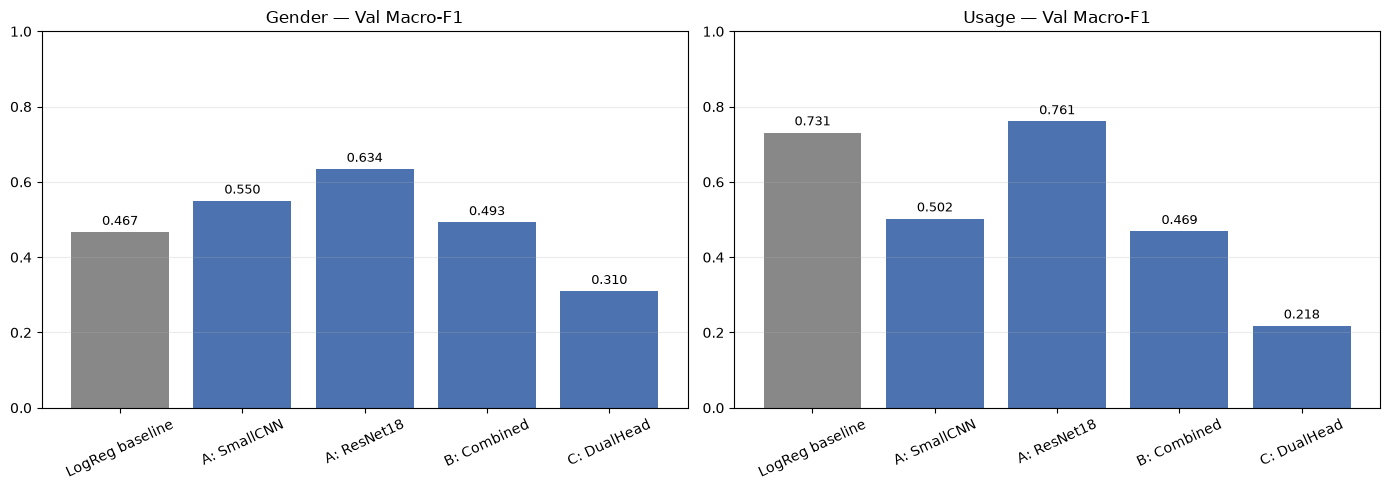

In [25]:
# ── Bar chart comparison ──────────────────────────────────────────────────────
gender_scores = {
    'LogReg baseline':    logreg_gender_f1,
    'A: SmallCNN':        f1_g_cnn,
    'A: ResNet18':        f1_g_resnet,
    'B: Combined':        f1_g_combined,
    'C: DualHead':        f1_g_dual,
}
usage_scores = {
    'LogReg baseline':    logreg_usage_f1,
    'A: SmallCNN':        f1_u_cnn,
    'A: ResNet18':        f1_u_resnet,
    'B: Combined':        f1_u_combined,
    'C: DualHead':        f1_u_dual,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, scores, title in zip(axes,
                              [gender_scores, usage_scores],
                              ['Gender — Val Macro-F1', 'Usage — Val Macro-F1']):
    bars = ax.bar(scores.keys(), scores.values(), color=['#888'] + ['#4C72B0'] * 4)
    ax.set_ylim(0, 1); ax.set_title(title); ax.tick_params(axis='x', rotation=25)
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
    ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

Best gender model: ResNet18 (val_f1=0.6343)
Best usage model:  ResNet18  (val_f1=0.7608)


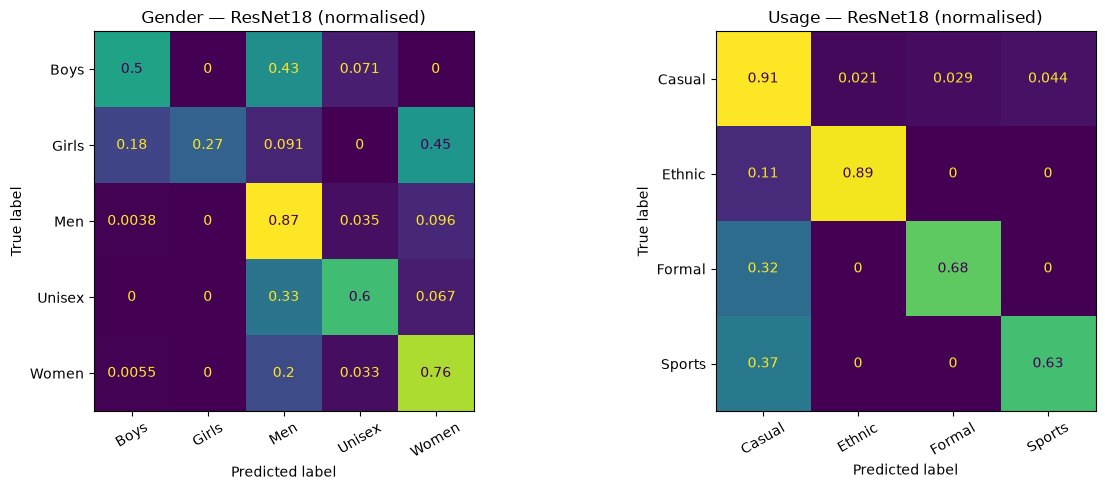


Gender classification report:
              precision    recall  f1-score   support

        Boys       0.64      0.50      0.56        14
       Girls       1.00      0.27      0.43        11
         Men       0.81      0.87      0.83       260
      Unisex       0.53      0.60      0.56        30
       Women       0.81      0.76      0.79       183

    accuracy                           0.79       498
   macro avg       0.76      0.60      0.63       498
weighted avg       0.79      0.79      0.78       498


Usage classification report:
              precision    recall  f1-score   support

      Casual       0.92      0.91      0.91       385
      Ethnic       0.80      0.89      0.84        36
      Formal       0.61      0.68      0.64        25
      Sports       0.66      0.63      0.65        52

    accuracy                           0.87       498
   macro avg       0.75      0.78      0.76       498
weighted avg       0.87      0.87      0.87       498



In [26]:
# ── Confusion matrices for best models ───────────────────────────────────────
def get_preds(model, loader):
    model.eval(); p, a = [], []
    with torch.no_grad():
        for batch in loader:
            inputs, labels = to_device(batch)
            p.extend(model(*inputs).argmax(1).cpu().numpy())
            a.extend(labels.cpu().numpy())
    return np.array(p), np.array(a)

g_pred_cnn,    g_true_cnn    = get_preds(gender_model,        val_loader_gender)
g_pred_resnet, g_true_resnet = get_preds(gender_resnet_model, val_loader_gender)
u_pred_cnn,    u_true_cnn    = get_preds(usage_model,         val_loader_usage)
u_pred_resnet, u_true_resnet = get_preds(usage_resnet_model,  val_loader_usage)

# One prediction/truth pair per approach, per target — FIX: previously the
# 'Combined' branch silently fell through to the DualHead model's predictions
# because the lookup dict mapped both 'Combined' and 'DualHead' to None and
# then always used `dual_model` regardless of which one actually won.
gender_predictions = {
    'SmallCNN': (g_pred_cnn,    g_true_cnn),
    'ResNet18': (g_pred_resnet, g_true_resnet),
    'Combined': (np.array(pred_gender_B), np.array(true_gender_B)),
    'DualHead': (pg_dual, ag_dual),
}
usage_predictions = {
    'SmallCNN': (u_pred_cnn,    u_true_cnn),
    'ResNet18': (u_pred_resnet, u_true_resnet),
    'Combined': (np.array(pred_usage_B), np.array(true_usage_B)),
    'DualHead': (pu_dual, au_dual),
}

best_gender_f1   = max(f1_g_cnn, f1_g_resnet, f1_g_combined, f1_g_dual)
best_gender_name = ['SmallCNN', 'ResNet18', 'Combined', 'DualHead'][
    [f1_g_cnn, f1_g_resnet, f1_g_combined, f1_g_dual].index(best_gender_f1)]
best_usage_f1    = max(f1_u_cnn, f1_u_resnet, f1_u_combined, f1_u_dual)
best_usage_name  = ['SmallCNN', 'ResNet18', 'Combined', 'DualHead'][
    [f1_u_cnn, f1_u_resnet, f1_u_combined, f1_u_dual].index(best_usage_f1)]

print(f'Best gender model: {best_gender_name} (val_f1={best_gender_f1:.4f})')
print(f'Best usage model:  {best_usage_name}  (val_f1={best_usage_f1:.4f})')

g_pred, g_true = gender_predictions[best_gender_name]
u_pred, u_true = usage_predictions[best_usage_name]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_predictions(
    g_true, g_pred, display_labels=gender_enc.classes_,
    ax=axes[0], xticks_rotation=30, colorbar=False, normalize='true')
axes[0].set_title(f'Gender — {best_gender_name} (normalised)')

ConfusionMatrixDisplay.from_predictions(
    u_true, u_pred, display_labels=usage_enc.classes_,
    ax=axes[1], xticks_rotation=30, colorbar=False, normalize='true')
axes[1].set_title(f'Usage — {best_usage_name} (normalised)')

plt.tight_layout()
plt.show()

print('\nGender classification report:')
print(classification_report(g_true, g_pred, target_names=gender_enc.classes_, zero_division=0))
print('\nUsage classification report:')
print(classification_report(u_true, u_pred, target_names=usage_enc.classes_,  zero_division=0))


## 13. Test-set prediction (submission)

In [27]:
# Load the test prediction template
pred_df = pd.read_csv(TEST_PRED_CSV)
pred_df['id'] = pred_df['id'].astype(str).str.strip()
print(pred_df.shape)
pred_df.head(3)

(5829, 5)


,id,gender,articleType,season,usage
0,52003,NaN,NaN,NaN,NaN
1,52007,NaN,NaN,NaN,NaN
2,52017,NaN,NaN,NaN,NaN


In [28]:
# ── Use the best gender and usage models for the final submission ──────────────
# FIX: previously this hardcoded BEST_GENDER_MODEL = gender_model /
# BEST_USAGE_MODEL = usage_model regardless of what Section 12's evaluation
# actually found — so the submitted predictions could silently NOT be your
# ultimate-judgement model. This now dispatches on best_gender_name /
# best_usage_name computed above.
#
# FIX: predict_test_multi previously looped over an undefined variable
# `loader` (its real parameters `loader_ids`/`meta_features` were unused) —
# it only ran because a same-shaped global `test_loader` happened to exist.
# Replaced with explicit, correctly-scoped inference functions below.

class TestDataset(Dataset):
    """Test-set dataset — image only (no labels). Returns (image, id)."""
    def __init__(self, ids, image_dir, transform):
        self.ids       = ids
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self): return len(self.ids)

    def __getitem__(self, i):
        img_id = self.ids[i]
        path   = self.image_dir / f"{img_id}.jpg"
        with Image.open(path) as im:
            img = self.transform(im.convert('RGB'))
        return img, img_id


test_ids = pred_df['id'].tolist()
test_ds  = TestDataset(test_ids, IMAGES_TEST_DIR, eval_transform)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, persistent_workers=(NUM_WORKERS > 0))


def build_test_metadata():
    """OHE-encode test metadata, or zero-fill with a loud warning if the
    prediction template doesn't carry the metadata columns."""
    if all(c in pred_df.columns for c in META_COLS):
        return ohe.transform(pred_df[META_COLS])
    print("WARNING: metadata columns not available in test CSV — using zero "
          "metadata. This will likely hurt performance for MultiInput models; "
          "verify styles_prediction.csv actually lacks these columns before "
          "trusting this submission.")
    return np.zeros((len(pred_df), META_DIM))

test_meta = build_test_metadata()


def predict_single_target(model, encoder):
    """Inference for a MultiInputNet (image+metadata -> one head) model."""
    model.eval(); results = {}
    idx = 0
    with torch.no_grad():
        for imgs, ids in tqdm(test_loader, desc='Predicting test set'):
            bs   = imgs.size(0)
            meta = torch.tensor(test_meta[idx:idx+bs], dtype=torch.float32).to(DEVICE)
            logits = model(imgs.to(DEVICE), meta)
            preds  = logits.argmax(1).cpu().numpy()
            for img_id, p in zip(ids, preds):
                results[img_id] = encoder.inverse_transform([p])[0]
            idx += bs
    return results


def predict_dual_head(model):
    """Inference for DualHeadNet — returns (gender_results, usage_results)."""
    model.eval(); g_results, u_results = {}, {}
    idx = 0
    with torch.no_grad():
        for imgs, ids in tqdm(test_loader, desc='Predicting test set (dual head)'):
            bs   = imgs.size(0)
            meta = torch.tensor(test_meta[idx:idx+bs], dtype=torch.float32).to(DEVICE)
            g_logit, u_logit = model(imgs.to(DEVICE), meta)
            g_preds = g_logit.argmax(1).cpu().numpy()
            u_preds = u_logit.argmax(1).cpu().numpy()
            for img_id, g, u in zip(ids, g_preds, u_preds):
                g_results[img_id] = gender_enc.inverse_transform([g])[0]
                u_results[img_id] = usage_enc.inverse_transform([u])[0]
            idx += bs
    return g_results, u_results


def predict_combined(model):
    """Inference for the combined-label model — splits the joint class
    back into (gender_results, usage_results)."""
    model.eval(); g_results, u_results = {}, {}
    idx = 0
    with torch.no_grad():
        for imgs, ids in tqdm(test_loader, desc='Predicting test set (combined)'):
            bs   = imgs.size(0)
            meta = torch.tensor(test_meta[idx:idx+bs], dtype=torch.float32).to(DEVICE)
            logits  = model(imgs.to(DEVICE), meta)
            preds   = logits.argmax(1).cpu().numpy()
            decoded = gender_usage_enc.inverse_transform(preds)
            for img_id, c in zip(ids, decoded):
                g, u = c.split('__')
                g_results[img_id] = g
                u_results[img_id] = u
            idx += bs
    return g_results, u_results


# ── Only run inference for approaches that actually won, avoiding wasted passes ──
if best_gender_name == 'DualHead' or best_usage_name == 'DualHead':
    g_from_dual, u_from_dual = predict_dual_head(dual_model)
if best_gender_name == 'Combined' or best_usage_name == 'Combined':
    g_from_combined, u_from_combined = predict_combined(combined_model)

gender_source = {
    'SmallCNN': lambda: predict_single_target(gender_model, gender_enc),
    'ResNet18': lambda: predict_single_target(gender_resnet_model, gender_enc),
    'Combined': lambda: g_from_combined,
    'DualHead': lambda: g_from_dual,
}
usage_source = {
    'SmallCNN': lambda: predict_single_target(usage_model, usage_enc),
    'ResNet18': lambda: predict_single_target(usage_resnet_model, usage_enc),
    'Combined': lambda: u_from_combined,
    'DualHead': lambda: u_from_dual,
}

gender_preds = gender_source[best_gender_name]()
usage_preds  = usage_source[best_usage_name]()

pred_df['gender'] = pred_df['id'].map(gender_preds)
pred_df['usage']  = pred_df['id'].map(usage_preds)

pred_df.to_csv(OUTPUT_DIR / 'task3_predictions.csv', index=False)
print(f"Predictions saved — {len(pred_df)} rows, "
      f"using gender={best_gender_name}, usage={best_usage_name}")
pred_df.head()


Predicting test set:   0%|          | 0/46 [00:00<?, ?it/s]

Predicting test set:   0%|          | 0/46 [00:00<?, ?it/s]

Predictions saved — 5829 rows, using gender=ResNet18, usage=ResNet18


,id,gender,articleType,season,usage
0,52003,Women,NaN,NaN,Casual
1,52007,Women,NaN,NaN,Casual
2,52017,Women,NaN,NaN,Casual
3,52021,Women,NaN,NaN,Casual
4,52023,Men,NaN,NaN,Casual


## 14. Save models & encoders

In [29]:
models_to_save = {
    'gender_multiinput_smallcnn.pt':       gender_model,
    'gender_multiinput_resnet18.pt':        gender_resnet_model,
    'usage_multiinput_smallcnn.pt':         usage_model,
    'usage_multiinput_resnet18.pt':         usage_resnet_model,
    'combined_gender_usage_smallcnn.pt':    combined_model,
    'dual_head_gender_usage.pt':            dual_model,
}

for fname, model in models_to_save.items():
    torch.save(model.state_dict(), OUTPUT_DIR / fname)
    print(f'Saved {fname}')

print(f'\nAll files in {OUTPUT_DIR}:')
for f in sorted(OUTPUT_DIR.iterdir()):
    size_mb = f.stat().st_size / 1e6
    print(f'  {f.name:<45} {size_mb:.1f} MB')

Saved gender_multiinput_smallcnn.pt
Saved gender_multiinput_resnet18.pt
Saved usage_multiinput_smallcnn.pt
Saved usage_multiinput_resnet18.pt
Saved combined_gender_usage_smallcnn.pt
Saved dual_head_gender_usage.pt

All files in ..\outputs\task3_models:
  baselines                                     0.0 MB
  combined_gender_usage_smallcnn.pt             5.4 MB
  dual_head_gender_usage.pt                     5.4 MB
  gender_encoder.joblib                         0.0 MB
  gender_multiinput_resnet18.pt                 45.4 MB
  gender_multiinput_smallcnn.pt                 5.4 MB
  gender_usage_encoder.joblib                   0.0 MB
  ohe_metadata.joblib                           0.0 MB
  task3_predictions.csv                         0.1 MB
  usage_encoder.joblib                          0.0 MB
  usage_multiinput_resnet18.pt                  45.4 MB
  usage_multiinput_smallcnn.pt                  5.4 MB
